# EXPLORATORY DATA ANALYSIS ON A DATASET

### Tasks:

In [1]:
# 1.	Data Cleaning and Preparation:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Cardiotocographic.csv")

# View basic info
print(df.info())
print(df.head())

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Handle missing values (fill with mean)
df = df.fillna(df.mean(numeric_only=True))

# Ensure correct data types
df = df.apply(pd.to_numeric, errors='ignore')

# Detect outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Remove extreme outliers
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None
           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  1

C:\Users\ibran\AppData\Local\Temp\ipykernel_22188\2450741358.py:19: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [2]:
# 2.Statistical Summary:
# Summary statistics
summary = df.describe()
print("\nStatistical Summary:\n", summary)

# Median & IQR
median = df.median()
iqr = df.quantile(0.75) - df.quantile(0.25)

print("\nMedian:\n", median)
print("\nIQR:\n", iqr)


Statistical Summary:
                LB          AC          FM          UC          DL     DS  \
count  883.000000  883.000000  883.000000  883.000000  883.000000  883.0   
mean   131.842621    0.004071    0.000603    0.004952    0.001545    0.0   
std      9.461012    0.003726    0.001337    0.002718    0.002218    0.0   
min    106.000000   -0.000122   -0.002467   -0.000101   -0.000124    0.0   
25%    125.000000    0.000000    0.000000    0.003098    0.000000    0.0   
50%    133.000000    0.003350    0.000000    0.005051    0.000000    0.0   
75%    138.000000    0.006719    0.000336    0.006927    0.003084    0.0   
max    160.000000    0.013861    0.006272    0.012072    0.008197    0.0   

          DP        ASTV        MSTV        ALTV        MLTV       Width  \
count  883.0  883.000000  883.000000  883.000000  883.000000  883.000000   
mean     0.0   42.401260    1.271275    3.170071    8.613856   67.795732   
std      0.0   15.079872    0.538496    6.036208    4.487502   3

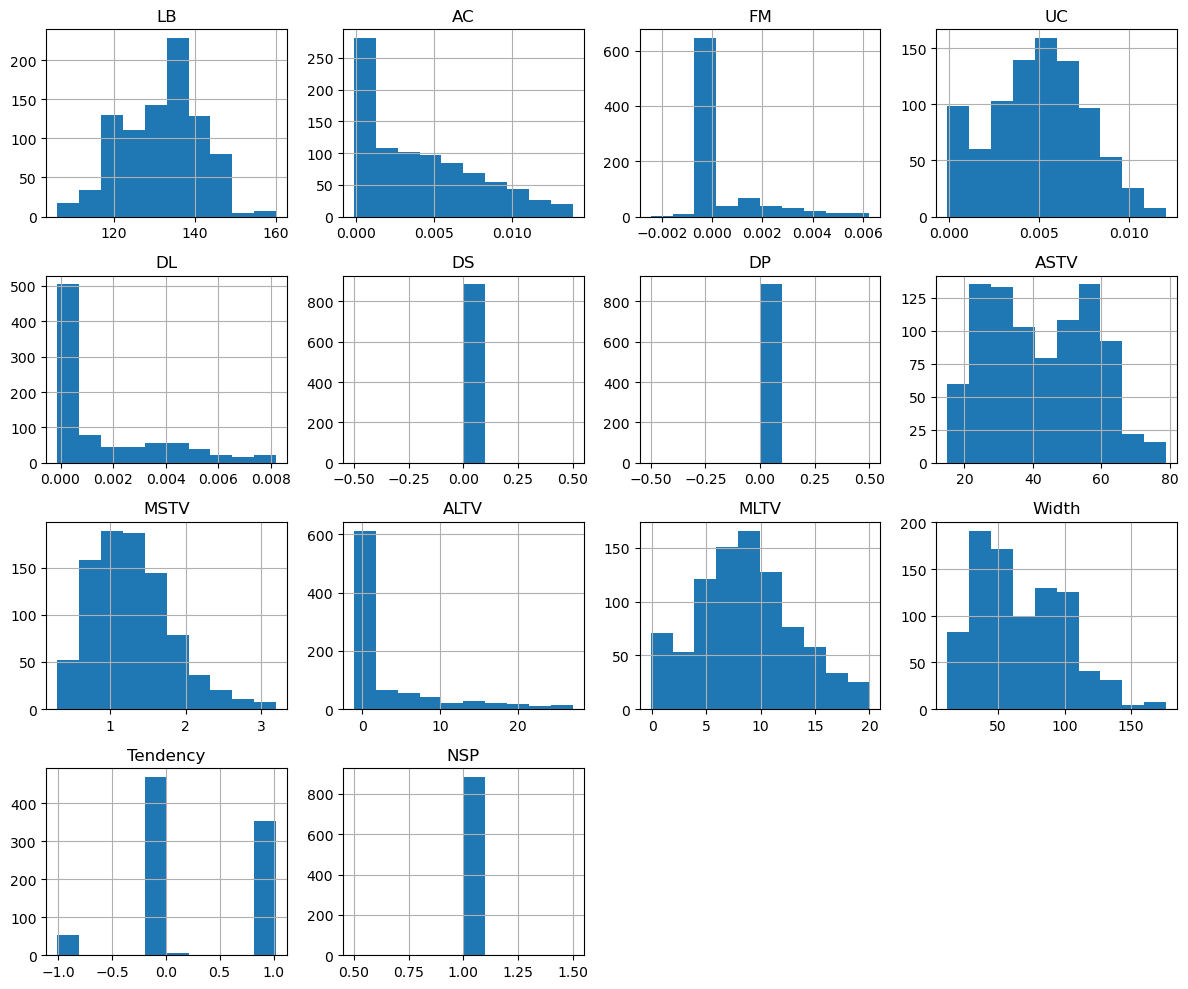

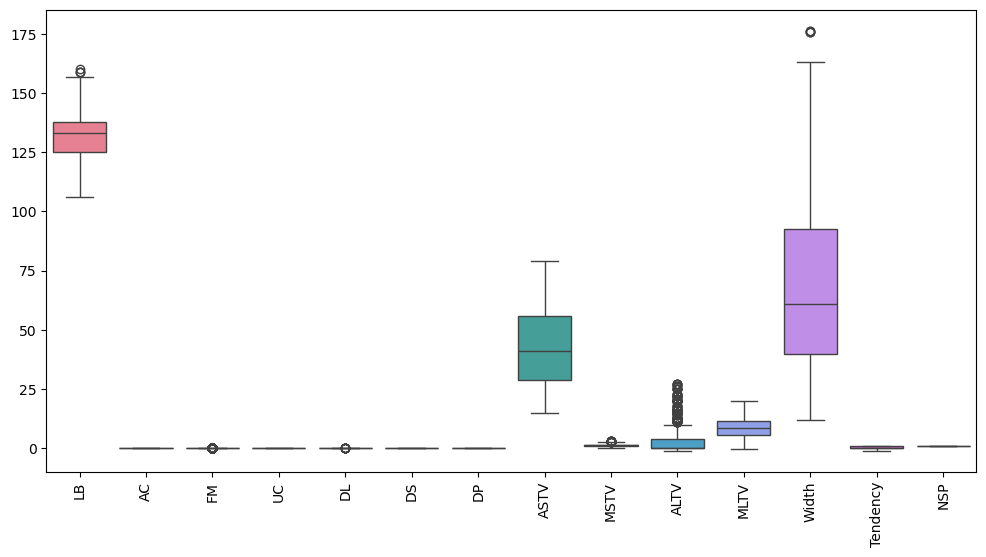

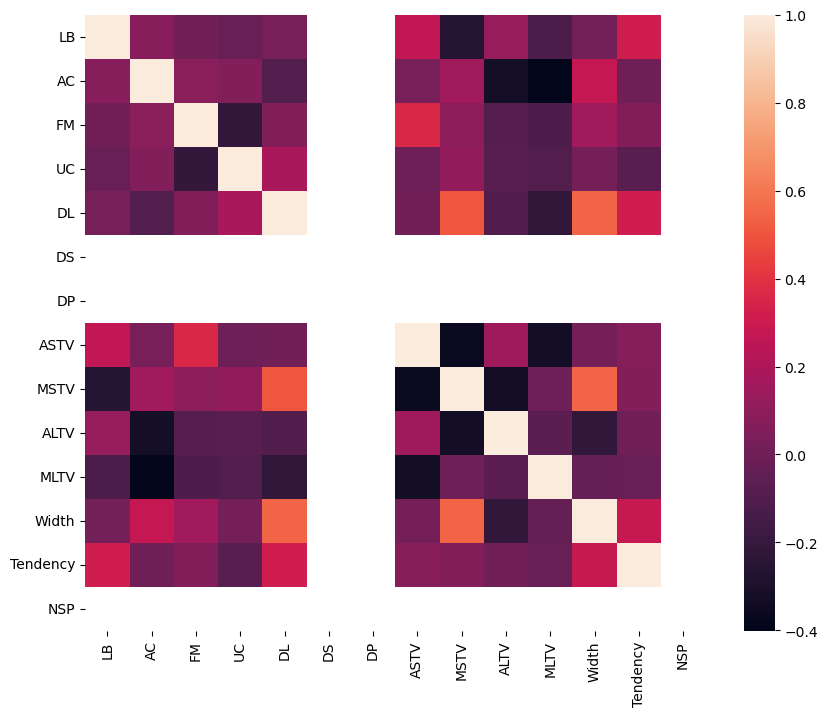

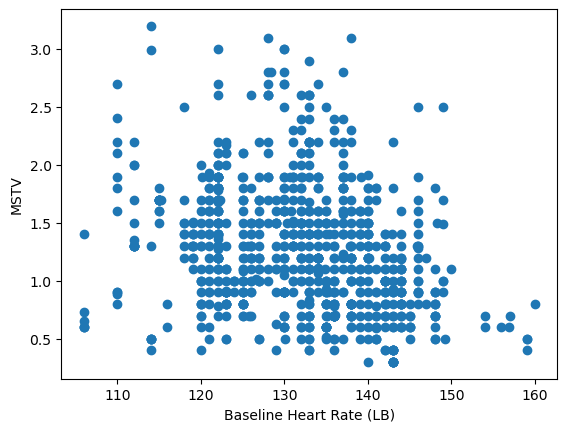

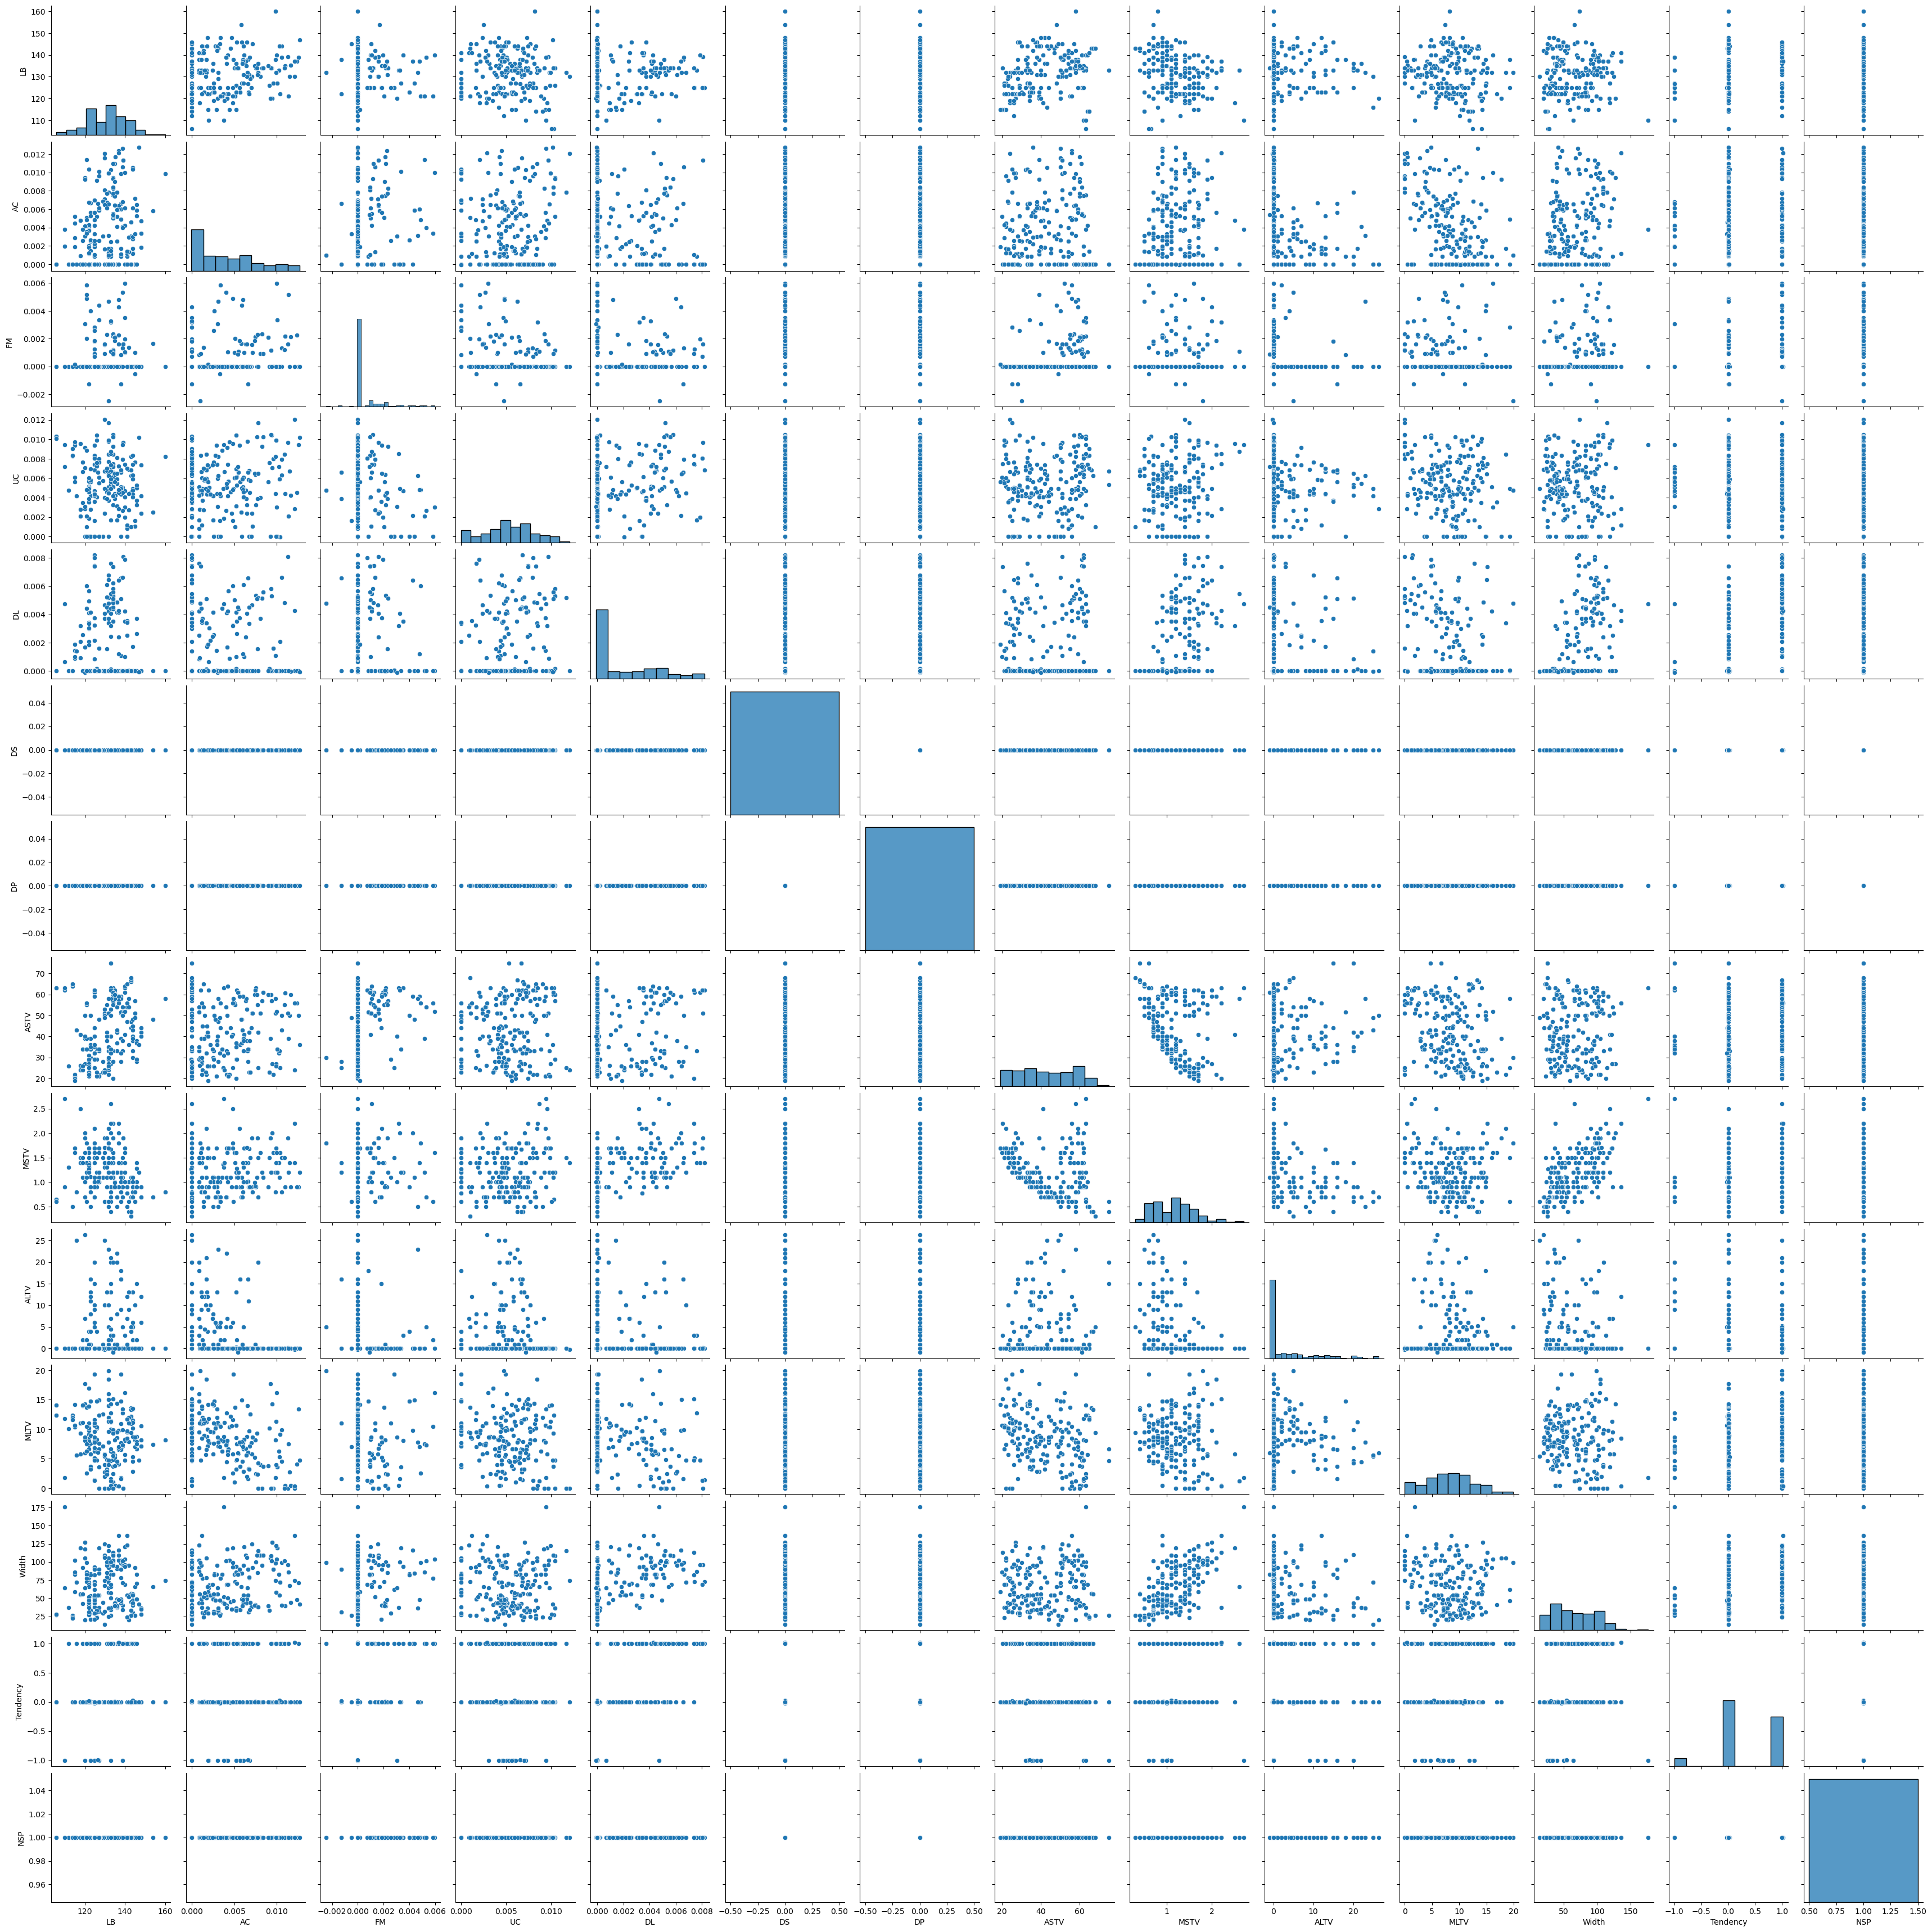

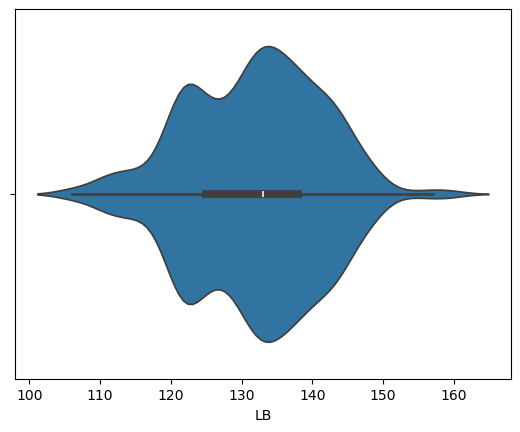

In [4]:
# 3.Data Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

# (a) Histograms
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# (b) Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# (c) Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.show()

# (d) Scatter Plot
plt.scatter(df['LB'], df['MSTV'])
plt.xlabel("Baseline Heart Rate (LB)")
plt.ylabel("MSTV")
plt.show()

# (e) Pair Plot (Advanced)
sns.pairplot(df.sample(200))  # sample for speed
plt.show()

# (f) Violin Plot
sns.violinplot(x=df['LB'])
plt.show()

In [5]:
# 4.Pattern Recognition and Insights:
# Correlation values
corr = df.corr()

# Find strong correlations
strong_corr = corr[(corr > 0.7) | (corr < -0.7)]
print("\nStrong Correlations:\n", strong_corr)


Strong Correlations:
            LB   AC   FM   UC   DL  DS  DP  ASTV  MSTV  ALTV  MLTV  Width  \
LB        1.0  NaN  NaN  NaN  NaN NaN NaN   NaN   NaN   NaN   NaN    NaN   
AC        NaN  1.0  NaN  NaN  NaN NaN NaN   NaN   NaN   NaN   NaN    NaN   
FM        NaN  NaN  1.0  NaN  NaN NaN NaN   NaN   NaN   NaN   NaN    NaN   
UC        NaN  NaN  NaN  1.0  NaN NaN NaN   NaN   NaN   NaN   NaN    NaN   
DL        NaN  NaN  NaN  NaN  1.0 NaN NaN   NaN   NaN   NaN   NaN    NaN   
DS        NaN  NaN  NaN  NaN  NaN NaN NaN   NaN   NaN   NaN   NaN    NaN   
DP        NaN  NaN  NaN  NaN  NaN NaN NaN   NaN   NaN   NaN   NaN    NaN   
ASTV      NaN  NaN  NaN  NaN  NaN NaN NaN   1.0   NaN   NaN   NaN    NaN   
MSTV      NaN  NaN  NaN  NaN  NaN NaN NaN   NaN   1.0   NaN   NaN    NaN   
ALTV      NaN  NaN  NaN  NaN  NaN NaN NaN   NaN   NaN   1.0   NaN    NaN   
MLTV      NaN  NaN  NaN  NaN  NaN NaN NaN   NaN   NaN   NaN   1.0    NaN   
Width     NaN  NaN  NaN  NaN  NaN NaN NaN   NaN   NaN   NaN   NaN

### 5.Conclusion:
Dataset cleaned and no missing values remain

Outliers handled → improved data quality

Strong correlations identified

Visualizations revealed distribution patterns

Useful for predicting fetal health condition